### Import Libraries

In [248]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import sklearn 
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.ensemble import RandomForestClassifier

### Load Dataset

In [15]:
data=datasets.load_iris()

### Description of the Dataset

In [23]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

### Printing the Dataset

In [83]:
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

### Labelling Columns names of Features and Targets

In [65]:
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df["Target"] = data.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


### Checking the Missing value of the Dataset

In [81]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Target               0
dtype: int64

### head() gives the first 5 rows and columns data of the Dataset

In [85]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### tail() gives the last 5 rows and columns data of the dataset

In [87]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


### Separating the Features and Targets from the Dataset :  x contains all features and y contains all targets of the dataset .

In [89]:
x = df.iloc[:,:-1]  #Features 
y = df.iloc[:,-1]   #Targets

### Converting data into Numpy Array 

In [91]:
#Convert into Numpy Arrays
x_arr = np.array(x)
y_arr = np.array(y)

In [103]:
print(x_arr)
print(x_arr.shape)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [105]:
print(y_arr)
print(y_arr.shape)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
(150,)


### Scaling / Standardizing / Normalizating the data

In [109]:
#Scaling / Normalization 
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

### Spliting the into Train Data & Test Data : test_size = 0.2 means that 80% data will be used for training purpose and remaining 20% data will be used for testing purpose. Here, random_state = 0 will make sure that on every split the data remains same 

In [111]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y_arr,test_size=0.2, random_state = 0)

# Logistic Reggression

### Traning the Model 

In [115]:
modelv2 = LogisticRegression()
modelv2.fit(x_train, y_train)

LogisticRegression()

### y_pred will store the data which has been predicted by the model after the training . 

In [117]:
y_pred = modelv2.predict(x_test)
y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

### y_test contains the Actual Targets value which we have separated during the train - test split 

In [119]:
y_test

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

### Accuracy of Logistic regression

In [138]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


### Classification Report of Logistic Regression

In [140]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Confusion Matrix of Logistic Regression

In [276]:
print(confusion_matrix(y_test, y_pred))

[[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]


### HeatMap of Logistic Regression

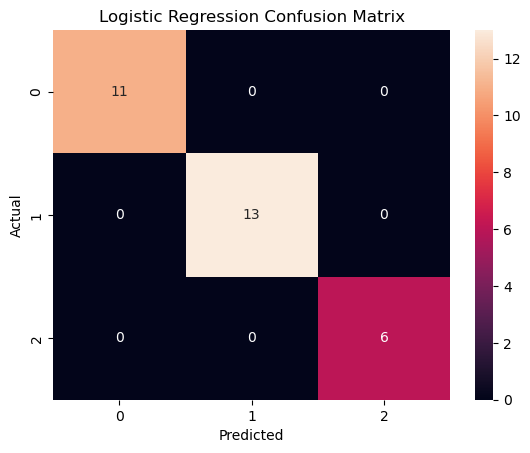

In [237]:
HeatMap_LR = confusion_matrix(y_test, y_pred)

sb.heatmap(HeatMap_LR, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# KNN Classifier

### Creating Model

In [159]:
knn = KNeighborsClassifier(n_neighbors=5)

### Training the Model

In [161]:
knn.fit(x_train, y_train)

KNeighborsClassifier()

### Prediction of the KNN Model

In [169]:
y_pred_knn = knn.predict(x_test)
y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

### This displays the actual target values from the test dataset, which are used to compare with the predicted values.

In [171]:
y_test

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

### Accuracy of KNN Model

In [175]:
print("Accuracy :",accuracy_score(y_pred_knn,y_test))

Accuracy : 1.0


### Classification Report of KNN Model

In [179]:
print("Classification Report : \n", classification_report(y_pred_knn, y_test))

Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Confusion Matrix of KNN Model

In [181]:
print("Confusion Matrix :\n",confusion_matrix(y_pred_knn, y_test))

Confusion Matrix :
 [[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]


### HeatMap of KNN Model

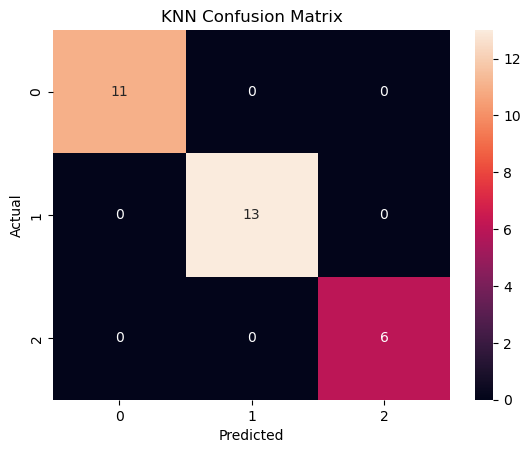

In [239]:
HeatMap_KNN = confusion_matrix(y_test, y_pred_knn)

sb.heatmap(HeatMap_KNN, annot=True, fmt='d')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SVM (Support Vector Classifier)

### Training the Model 

In [192]:
model = SVC()
model.fit(x_train, y_train)

SVC()

### y_pred_svc contains the value which are predicted by model 

In [194]:
y_pred_svc = model.predict(x_test)
y_pred_svc

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

### This displays the actual target values from the test dataset, which are used to compare with the predicted values.

In [196]:
y_test

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

### Accuracy of SVC Model 

In [200]:
print("Accuracy :",accuracy_score(y_pred_svc, y_test))

Accuracy : 1.0


### Classification Report of SVC Model

In [202]:
print("Classification_Report : \n",classification_report(y_pred_svc, y_test))

Classification_Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Confusion Matrix of SVC Model

In [204]:
print("Confusion Matrix :\n",confusion_matrix(y_pred_svc, y_test))

Confusion Matrix :
 [[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]


### HeatMap of SVC Model 

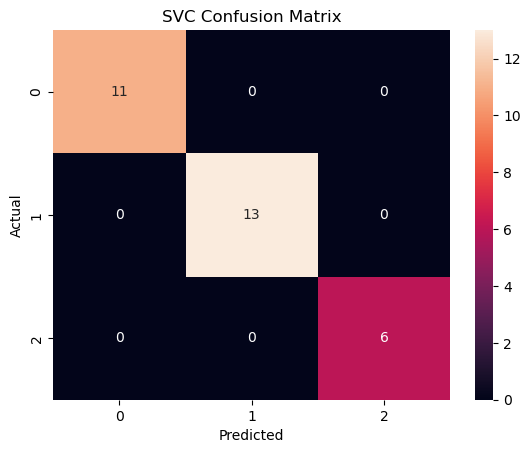

In [241]:
HeatMap_SVC = confusion_matrix(y_test, y_pred_svc)

sb.heatmap(HeatMap_SVC, annot=True, fmt='d')
plt.title("SVC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Decision Tree

### Creating Model 

In [217]:
dt_classifier = DecisionTreeClassifier(random_state = 42)

### Training the Model 

In [219]:
dt_classifier.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

### y_pred_dt contains values which has been predicted by the model 

In [223]:
y_pred_dt = dt_classifier.predict(x_test)
y_pred_dt

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

### This displays the actual target values from the test dataset, which are used to compare with the predicted values.

In [225]:
y_test

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

### Accuracy of Decision Tree Classifier

In [231]:
print("Accuracy :",accuracy_score(y_pred_dt, y_test))

Accuracy : 1.0


### Classification Report of Decision Tree Classifier

In [229]:
print("Classification_Report : \n",classification_report(y_pred_dt, y_test))

Classification_Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Confusion Matrix of Decision Tree Classifier

In [233]:
print("Confusion_Matrix :\n",confusion_matrix(y_pred_dt, y_test))

Confusion_Matrix :
 [[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]


### Heatmap of Decision Tree Classifier

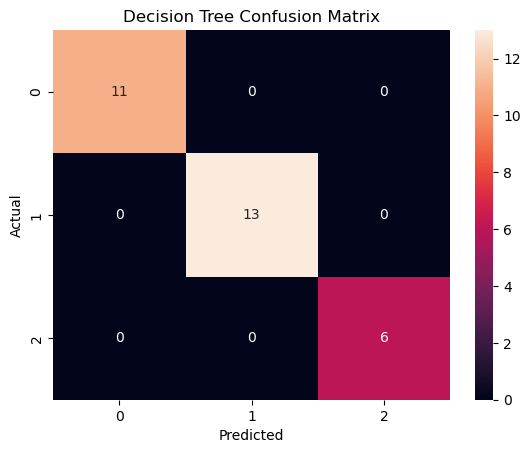

In [243]:
HeatMap_DT = confusion_matrix(y_test, y_pred_dt)

sb.heatmap(HeatMap_DT, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Random Forest

### Creating the Model 

In [250]:
rf_classifier = RandomForestClassifier(random_state = 42)

### Training the Model 

In [252]:
rf_classifier.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

### y_pred_rf contains the value which are produced after training the model 

In [256]:
y_pred_rf = rf_classifier.predict(x_test)
y_pred_rf

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

### This displays the actual target values from the test dataset, which are used to compare with the predicted values.

In [258]:
y_test

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

### Accuracy of Random Forest 

In [262]:
print("Accuracy : ",accuracy_score(y_pred_rf, y_test))

Accuracy :  1.0


### Classification Report of Random Forest 

In [264]:
print("Classification Report :\n",classification_report(y_pred_rf, y_test))

Classification Report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### Confusion Matrix of Random Forest 

In [266]:
print("Confusion Matrix :\n",confusion_matrix(y_pred_rf, y_test))

Confusion Matrix :
 [[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]


### HeatMap of Random Forest

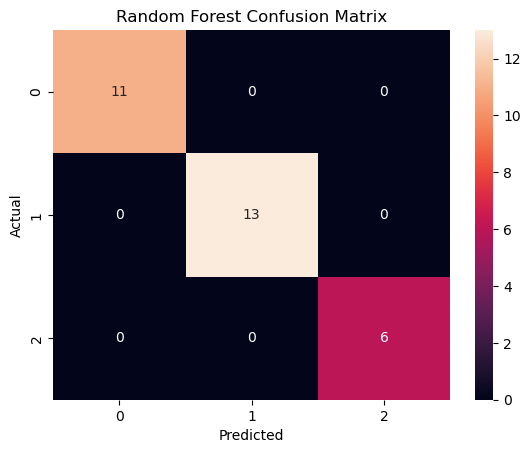

In [274]:
HeatMap_RF = confusion_matrix(y_test, y_pred_rf)

sb.heatmap(HeatMap_RF, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Conclusion

**In this, multiple machine learning algorithms including Logistic Regression, K-Nearest Neighbors (KNN), Support Vector Machine (SVM), Decision Tree, and Random Forest were applied to classify iris flower species based on their features. All models achieved 100% accuracy on the test dataset. This is mainly because the Iris dataset is well-structured, clean, and the classes are highly separable, making it easier for different algorithms to learn and predict accurately. Since all models performed equally well in terms of accuracy, model selection in this case depends on other factors such as simplicity, interpretability, and computational efficiency.**

**Logistic Regression provides a simple and fast solution, while ensemble methods like Random Forest are more robust and suitable for more complex datasets. 
Overall, this project demonstrates the importance of data preprocessing, model comparison, and evaluation in building effective machine learning models.**

Key Learnings : 
- Importance of data preprocessing and scaling
- Understanding differences between classification algorithms
- Evaluating models using accuracy, confusion matrix, and classification report
- Comparing multiple models instead of relying on a single approach